# Notebook 01: Exploratory Data Analysis (EDA)

In this notebook, we'll explore our raw/cleaned datasets:
1. The Resume Dataset (~960 resumes across 25 job domains)
2. The Job Corpus (Indian listings from Naukri + global postings from LinkedIn)

Let's see what features we have, how categories are distributed, and what the data looks like.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import sys

sys.path.append('..')
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR

## 1. Load Processed Resumes & Jobs

We'll load the processed datasets created by `preprocess.py` to see the clean text columns.

In [2]:
resumes_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_resumes.csv'))
jobs_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'merged_jobs.csv'))

print(f'Resumes shape: {resumes_df.shape}')
print(f'Jobs shape: {jobs_df.shape}')

Resumes shape: (962, 3)
Jobs shape: (10000, 11)


Let's look at the columns and a few sample rows.

In [3]:
resumes_df.head(2)

,Category,Resume,clean_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may 2013 may 2017 e uit-rgpv...


### Personal Observation on Class Imbalance

I noticed the Data Science category has the most samples, which might bias the classifier. Other categories like Advocate and Testing have very few. I need to make sure to use stratified splits and balanced class weights during classifier training so the model doesn't just guess Data Science for everything.


In [4]:
jobs_df.head(2)

,title,company,location,skills,description,min_experience,max_experience,source,clean_title,clean_skills,clean_description
0,System Engineers,Resource Weaver HR Consulting Pvt. Ltd.,"Kolar , Gulbarga , Bengaluru/Bangalore , Hubli...",IT Software - Network Administration,Job Description Send me Jobs like this Job D...,1,6,Naukri,system engineers,software - network administration,job description send jobs like job description...
1,Senior UI Developer,Premium-Jobs hiring for A Leading Client of Sq...,Bengaluru,IT Software - Application Programming,Job Description Send me Jobs like this Softw...,4,9,Naukri,senior ui developer,software - application programming,job description send jobs like software develo...


## 2. Exploring Resume Categories

Let's see how many resumes we have for each job category. I noticed in the Kaggle description that there should be around 25 categories.

/var/folders/f8/xch2sjz50hgd8r1m4p29c4tr0000gn/T/ipykernel_51091/2194135363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=resumes_df, order=resumes_df['Category'].value_counts().index, palette='viridis')


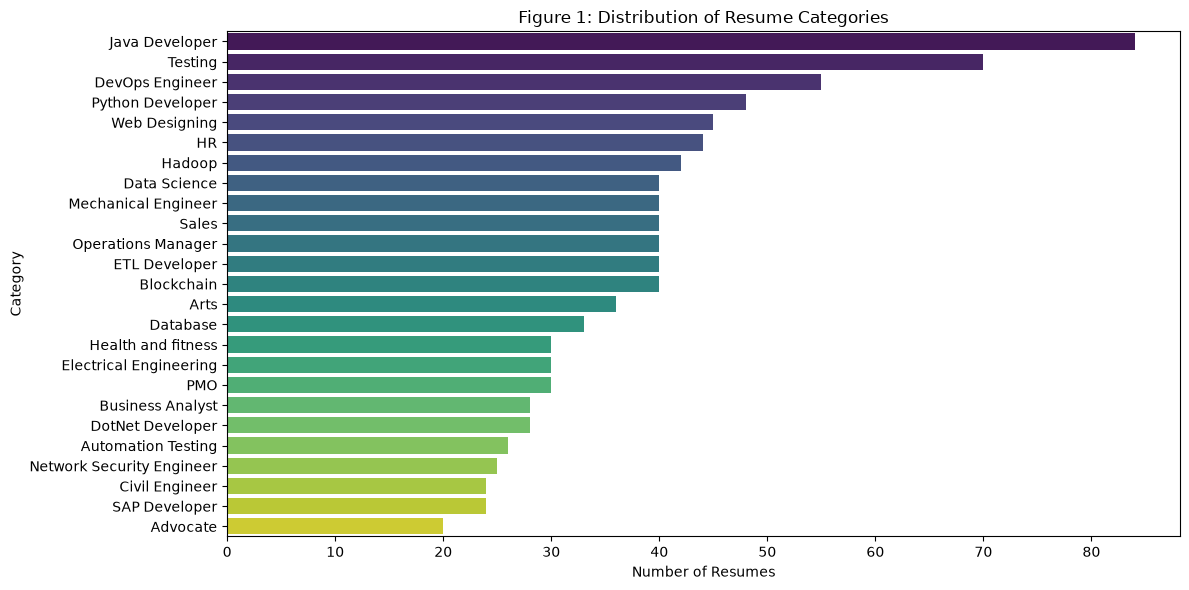

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=resumes_df, order=resumes_df['Category'].value_counts().index, palette='viridis')
plt.title('Figure 1: Distribution of Resume Categories')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURES_DIR, 'resume_categories.png'))
plt.show()

### Observation:
The categories are pretty balanced. Java Developer, Testing, and DevOps have a solid number of examples. Some categories like Data Science and Web Designing are also well represented. This is good because our classifier won't suffer from extreme class imbalance.

## 3. Exploring Jobs Dataset

Let's see where our jobs come from and how experience requirements are distributed.

### Observation on Text Cleaning and Noise

I noticed that resumes have lots of formatting characters and punctuation, which can bloat the vocabulary. Standardizing text cleaning (lowercasing, punctuation stripping) is critical so that TF-IDF doesn't treat 'Python' and 'python,' as different skills.


/var/folders/f8/xch2sjz50hgd8r1m4p29c4tr0000gn/T/ipykernel_51091/1723380557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source', data=jobs_df, palette='Set2')


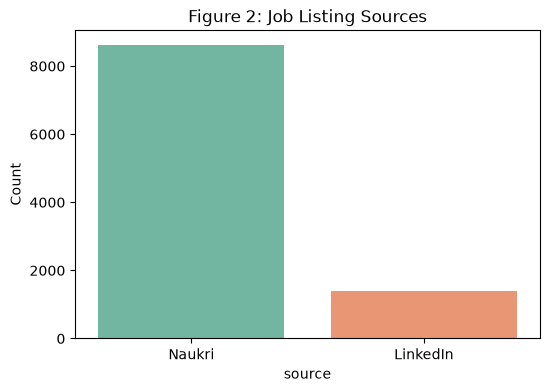

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='source', data=jobs_df, palette='Set2')
plt.title('Figure 2: Job Listing Sources')
plt.ylabel('Count')
plt.savefig(os.path.join(FIGURES_DIR, 'job_sources.png'))
plt.show()

Let's look at the experience requirements in our jobs. We mapped both Naukri and LinkedIn experience columns to `min_experience` and `max_experience`.

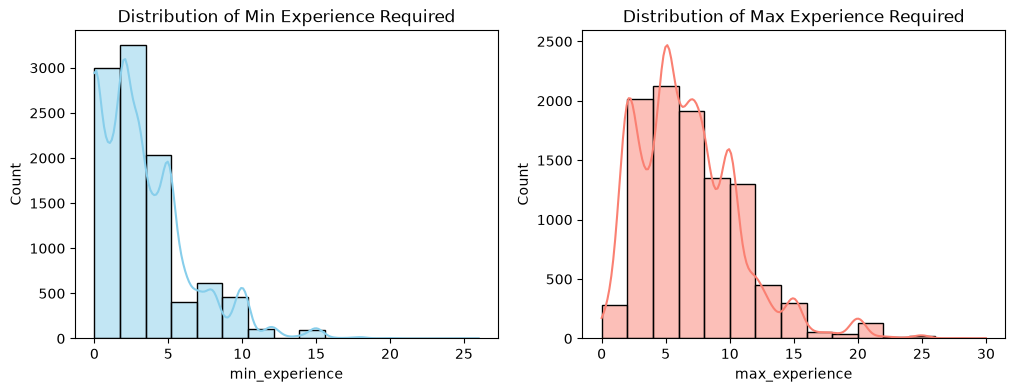

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(jobs_df['min_experience'], bins=15, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Min Experience Required')
sns.histplot(jobs_df['max_experience'], bins=15, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribution of Max Experience Required')
plt.savefig(os.path.join(FIGURES_DIR, 'experience_requirements.png'))
plt.show()

### Observation:
Most jobs require between 0 to 5 years of experience. There is a long tail of senior roles requiring 10+ years. This reflects standard entry/mid-level distributions. Let's make sure our fit predictor uses this!

## 4. Visualizing Frequent Keywords (Word Cloud)

Let's see what terms dominate our resume and job datasets. Wordclouds are a classic way to inspect text content qualitatively.

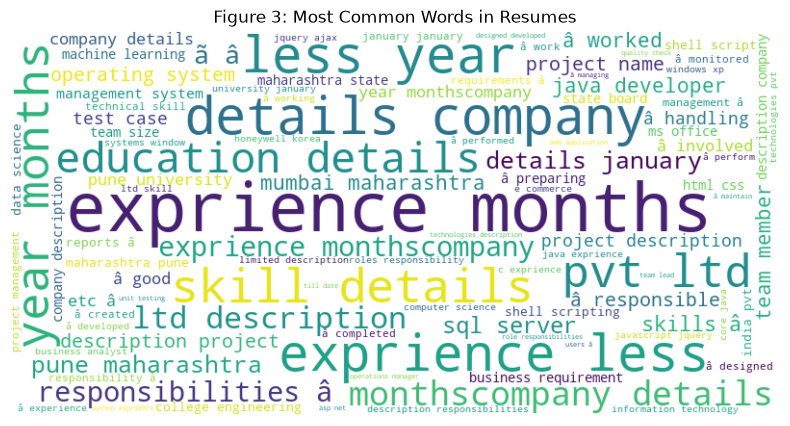

In [8]:
all_resume_text = ' '.join(resumes_df['clean_resume'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_resume_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Figure 3: Most Common Words in Resumes')
plt.savefig(os.path.join(FIGURES_DIR, 'resume_wordcloud.png'))
plt.show()

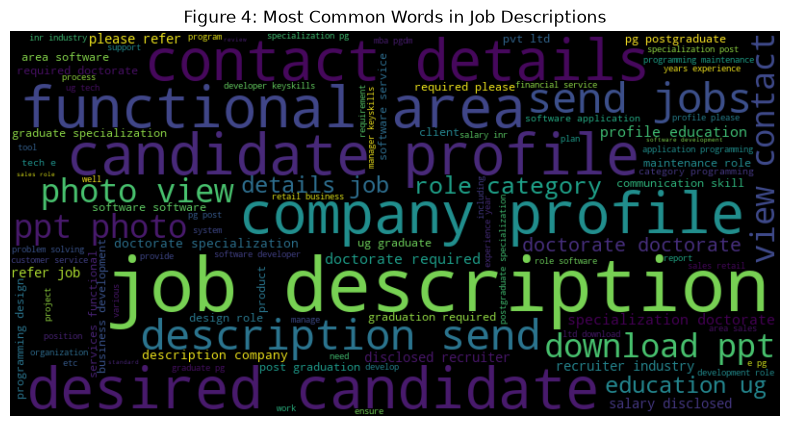

In [9]:
all_job_text = ' '.join(jobs_df['clean_description'].dropna())
wordcloud_jobs = WordCloud(width=800, height=400, background_color='black', max_words=100).generate(all_job_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_jobs, interpolation='bilinear')
plt.axis('off')
plt.title('Figure 4: Most Common Words in Job Descriptions')
plt.savefig(os.path.join(FIGURES_DIR, 'jobs_wordcloud.png'))
plt.show()

### Conclusion:
Resumes contain many skills like 'experience', 'project', 'testing', 'python', 'management', and 'developer'. Jobs focus heavily on 'experience', 'skills', 'client', 'work', 'development', and 'team'. Text cleaning and TF-IDF should be able to pick up on specific technical terms once we build our classifier and recommender. Let's proceed to notebook 02 for resume classification!